## IMPORTS


In [3]:
import pandas as pd
import numpy as np
import optuna
from sklearn.impute import SimpleImputer
import os
from imblearn.pipeline import Pipeline 
import xgboost as  xgb
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, precision_score
import sys
from sklearn.experimental import enable_iterative_imputer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib
import logging
from sklearn.model_selection import train_test_split
import optuna
from sklearn.svm import SVC
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")
import optuna.visualization as ov
import optuna.visualization.matplotlib as ov  
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



ruta_raiz = os.path.abspath('..')
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

%load_ext autoreload
%autoreload 2
from Data_preprocesing.IQRCapper import IQRCapper



c:\Users\gonzalo.iglesias\AppData\Local\miniconda3\envs\machinelearning2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOS OUTPUTS DE OPTUNA QUE LOS IMPRIMA EN UN TXT PARA SIN VOLVERLO A CORRER

In [19]:
log_file = logging.FileHandler("optuna_resultados.txt")
log_file.setFormatter(logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s'))
optuna.logging.get_logger("optuna").addHandler(log_file)

In [7]:
TRAIN = True
SAVE_MODEL = False
CHARGE_XBOOST= True
CHOOSE_SAMPLER_XGBOOST = False

## LOAD DATA + SAVE FUCTION


In [3]:
X_train = pd.read_csv("../Train_test_split/X_train.csv")
y_train = pd.read_csv("../Train_test_split/y_train.csv")
X_test = pd.read_csv("../Train_test_split/X_test.csv")
y_test = pd.read_csv("../Train_test_split/y_test.csv")



target_folder = '../comparations'

def save_experiment(model_name, imbalance_method, accuracy, precision, recall, f1, roc_auc):
    new_result = {
        'Model': [model_name],
        'Imbalance_Method': [imbalance_method],
        'Accuracy': [round(accuracy, 4)],
        'Precision': [round(precision, 4)],
        'Recall': [round(recall, 4)],
        'F1_Score': [round(f1, 4)],
        'ROC_AUC': [round(roc_auc, 4)]
    }
    df_new = pd.DataFrame(new_result)
    
    # Point the file to inside the folder
    csv_file = f'{target_folder}/imbalance_results.csv'
    
    if os.path.exists(csv_file):
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(csv_file, index=False)
        
    print(f"✅ Success! Results for {model_name} + {imbalance_method} saved in the '{target_folder}' folder.")


## XGBOOST

In [5]:
num_classes = int(y_train['customer_segment'].nunique())
modelo_xgb = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=num_classes, 
    random_state=42,
    eval_metric='mlogloss'
)

## DEFINIMOS LOS RANGOS Y CATEGORIAS QUE QUEREMOS QUE OPTUNA OPTIMICE

In [23]:
if CHOOSE_SAMPLER_XGBOOST:
    imbalance_methods = {
        "Baseline": None,
        "RandomUnderSampler":     RandomUnderSampler(random_state=42),
        "TomekLinks":             TomekLinks(),
        "RandomOverSampler":      RandomOverSampler(random_state=42),
        "SMOTE":                  SMOTE(random_state=42),
        "ADASYN":                 ADASYN(random_state=42),
        "SMOTETomek":             SMOTETomek(random_state=42),
        "SMOTEENN":               SMOTEENN(random_state=42),
    }


    for method_name, sampler in imbalance_methods.items():
        print(f"\n--- {method_name} ---")

        

        if sampler is None:
            pipe = Pipeline([
                ('capping_outliers', IQRCapper(factor=1.5)),
                ('imputacion', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler()),
                ('classifier', modelo_xgb)])
        else:
            pipe = Pipeline([
                ('capping_outliers', IQRCapper(factor=1.5)),
                ('imputacion', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler()),
                ('sampler', sampler), 
                ('classifier', modelo_xgb)])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)

        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

        print(f"Accuracy: {accuracy:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

        """save_experiment(
            model_name="XgBoost",
            imbalance_method=method_name,
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            roc_auc=roc_auc
        )"""

In [ ]:
def objective(trial):
    

    # ESCOGER TIPO DE MUESTREO
    nombre_metodo = "TomekLinks" 
    metodo_elegido = TomekLinks()
    # ESCOGER LOS HIPERPARÁMETROS DE XGBOOST
    param_n_estimators = trial.suggest_int('n_estimators', 50, 1000)
    param_max_depth = trial.suggest_int('max_depth', 3, 8)  
    param_learning_rate = trial.suggest_float('learning_rate', 0.005, 0.3, log=True)
    param_gamma = trial.suggest_float('gamma', 0.0, 5.0 )
    param_lambda = trial.suggest_float('lambda', 0.5, 10.0, log=True) 
    param_alpha = trial.suggest_float('alpha', 0.0, 5.0)
    param_subsample = trial.suggest_float('subsample', 0.5, 1.0)
    param_colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    param_min_child_weight = trial.suggest_int(  'min_child_weight', 1, 20)  
    param_max_delta_step = trial.suggest_float('max_delta_step', 0.0, 1.0)
    param_iqr_factor = trial.suggest_float('iqr_factor', 1.0, 3.0)



    modelo_xgb = xgb.XGBClassifier(
        n_estimators = param_n_estimators,
        max_depth = param_max_depth,
        learning_rate = param_learning_rate,
        gamma = param_gamma,
        reg_lambda = param_lambda,
        reg_alpha = param_alpha,
        subsample = param_subsample,
        colsample_bytree = param_colsample_bytree,
        min_child_weight = param_min_child_weight,
        max_delta_step = param_max_delta_step,
        objective = 'multi:softmax',
        eval_metric = 'mlogloss',
        num_class = len(np.unique(y_train)),
        random_state = 42,
        n_jobs = -1
    )

    pipeline = Pipeline([
        ('capping_outliers', IQRCapper(factor=param_iqr_factor)),
        ('imputacion',       SimpleImputer(strategy='mean')),
        ('scaler',           StandardScaler()),
        ('sampler', metodo_elegido),
        ('clf',              modelo_xgb)
    ])

    


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring = 'roc_auc_ovr_weighted',
    cv=cv,
    n_jobs=1)

    return np.mean(scores)



if TRAIN:
    best_value = [None]
    no_improve_count = [0]

    def early_stopping_callback(study, trial):
        if best_value[0] is None or study.best_value > best_value[0]:
            best_value[0] = study.best_value
            no_improve_count[0] = 0
        else:
            no_improve_count[0] += 1
        if no_improve_count[0] >= 50:
            study.stop()

    study = optuna.create_study(direction="maximize", 
                                sampler=optuna.samplers.TPESampler(seed=42),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)  
)
    study.optimize(objective, n_trials=200, callbacks=[early_stopping_callback], show_progress_bar = True)
    joblib.dump(study, 'Studys/studyXgBoost.pkl')

    print(f"Better F1-Score Macro: {study.best_value:.4f}")
    print("Best founded combination:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")

    with open("mejores_parametros_XGBoost.txt", "w") as archivo:
        archivo.write("Best hyperparameters found for XGBoost")
        archivo.write("="*40 + "\n")
        for key, value in study.best_params.items():
            archivo.write(f"  - {key}: {value}\n")

    print("Parameters successfully saved in 'mejores_parametros_XGBoost.txt'!")
    
            
  

In [ ]:
if TRAIN:
    study = joblib.load('Studys/studyXgBoost.pkl')

    ov.plot_param_importances(study)
    plt.tight_layout() 
    plt.savefig("Graphs/XgBoost_param_importances.png")
    plt.close() 
    ov.plot_optimization_history(study)
    plt.tight_layout()
    plt.savefig("Graphs/XgBoost_optimization_history.png")
    plt.close()
    ov.plot_slice(study)
    plt.tight_layout()
    plt.savefig("Graphs/XgBoost_slice.png")
    plt.close()

GUARDAMOS EL MEJOR MODELO

In [ ]:
if TRAIN:
    print("Reconstructing...")
    
    mejor_metodo_nombre = "TomekLinks"
    mejor_metodo = TomekLinks()


    mejor_xgb = xgb.XGBClassifier(
        n_estimators=study.best_params['n_estimators'],
        max_depth=study.best_params['max_depth'],
        learning_rate=study.best_params['learning_rate'],
        subsample=study.best_params['subsample'],
        colsample_bytree=study.best_params['colsample_bytree'],
        objective = 'multi:softprob',
        eval_metric='mlogloss',
        tree_method = 'hist', 
        random_state=42,
        n_jobs=-1
    )
    print(study.best_params)


    pasos_finales = [
        ('capping_outliers', IQRCapper(factor=study.best_params["iqr_factor"])),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('sampler', mejor_metodo),
        ('clf', mejor_xgb)
    ]

    pipeline_final = Pipeline(pasos_finales)



if SAVE_MODEL:
    joblib.dump(pasos_finales, 'Modelos/modelo_xgboost_ganador.pkl')
    print("Final model trained and saved correctly as 'modelo_xgboost_ganador.pkl'!")
        


Reconstruyendo y entrenando el modelo final con toda la data...


In [41]:
if CHARGE_XBOOST:
    pasos_cargados = joblib.load('Modelos/modelo_xgboost_ganador.pkl')
    pipeline = Pipeline(pasos_cargados)
    X_train = pd.read_csv("../Train_test_split/X_train.csv")
    y_train = pd.read_csv("../Train_test_split/y_train.csv")
    X_test = pd.read_csv("../Train_test_split/X_test.csv")
    y_test = pd.read_csv("../Train_test_split/y_test.csv")
    pipeline.fit(X_train, y_train)


    y_pred       = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba, 
                            multi_class='ovr',  
                            average='weighted')  

    new_result = {
        'Model': ["XGBoost"],
        'Imbalance_Method': [pasos_cargados[3][1]],
        'Accuracy': [round(accuracy, 4)],
        'Precision': [round(precision, 4)],
        'Recall': [round(recall, 4)],
        'F1_Score': [round(f1, 4)],
        'ROC_AUC': [round(roc_auc, 4)]
    }

    print(study.best_params)
    



{'meta_solver': 'lbfgs', 'meta_C': 0.8471801418819978, 'meta_max_iter': 1997, 'meta_tol': 2.9380279387035334e-05, 'meta_class_weight': None, 'xgb_n_estimators': 440, 'xgb_max_depth': 6, 'xgb_learning_rate': 0.09078835431980901, 'xgb_subsample': 0.5102922471479012, 'xgb_colsample_bytree': 0.9849549260809971, 'xgb_gamma': 4.162213204002109, 'xgb_lambda': 0.9445600138094694, 'xgb_alpha': 0.9091248360355031, 'xgb_min_child_weight': 4, 'rf_n_estimators': 187, 'rf_max_depth': 12, 'rf_max_features': 0.602361513049481, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 7, 'svm_C': 0.03613894271216528, 'svm_gamma': 0.0014742753159914669, 'lgbm_n_estimators': 215, 'lgbm_max_depth': 5, 'lgbm_learning_rate': 0.12448918446337819, 'lgbm_num_leaves': 37, 'lgbm_subsample': 0.7571172192068059, 'lgbm_colsample_bytree': 0.7962072844310213, 'lgbm_alpha': 0.23225206359998862, 'lgbm_lambda': 3.0860579740535368, 'iqr_factor': 1.341048247374583}


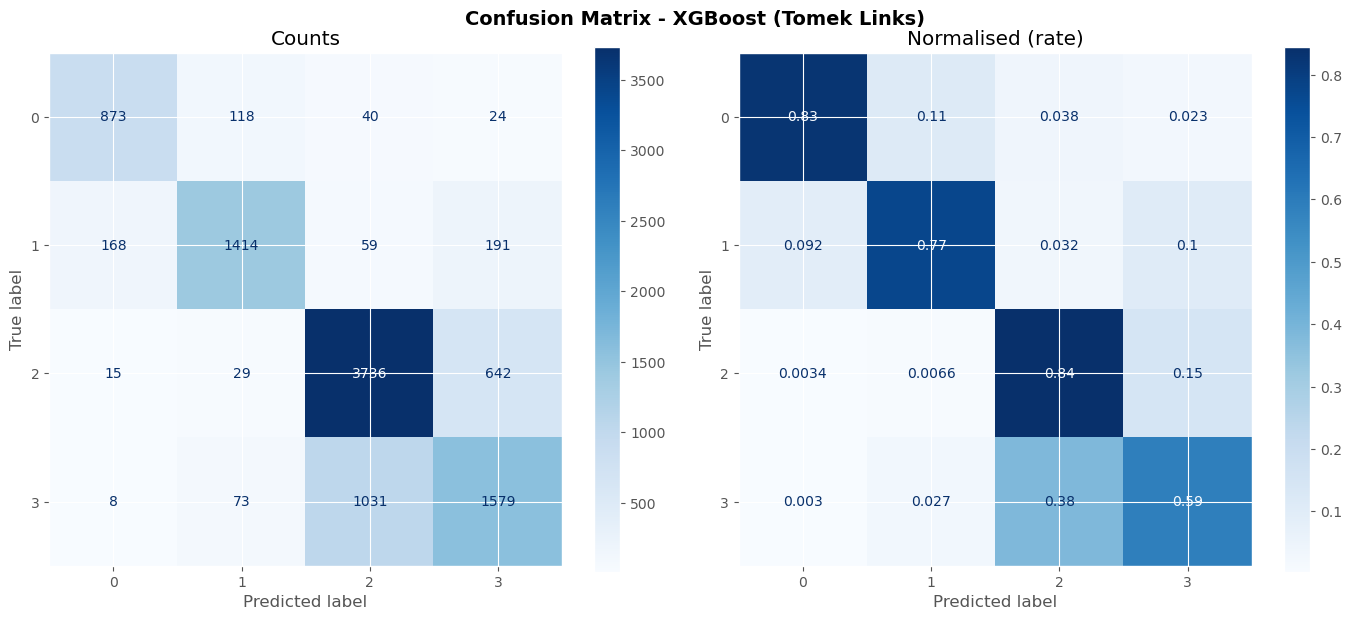

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Counts')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize='true')).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Normalised (rate)')

plt.suptitle('Confusion Matrix - XGBoost (Tomek Links)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Guardar el gráfico
os.makedirs('Graphs', exist_ok=True)
plt.savefig('Graphs/XGBoost_confussionMatrix.png', dpi=150, bbox_inches='tight')

plt.show()